## 1. C与面向对象
C语言是面向过程的语言，但我们可以借助C++/JAVA面向对象思想，实现类似"继承”、"多态”、“封装”、“重载"的功能。从而服务于架构设计。

## 2. C与"继承"
继承是使用已存在的类作为基础建立新的类的技术。新的类可以增加新的数据类型或者方法，也可以使用父类的功能，但不能选择性的继承父类。通过继承可以很好的复用以前的代码，提高开发效率。


### 2.1 C与"继承"

下面是c++的代码，如何通过c语言对下面例子进行改造，实现继承

In [ ]:
#include <iostream>
using namespace std;
//基类
class shape{
protected:
    int width;
    int height;
public:
    void setWidth(int w) {
        width = w;
    }
    void setHeight(int h) {
        height = h;
    }
};
//派生类
class rectangle : public shape{
public:
    int getArea(){ 
        return (width * height)；
    }
};
int main(void){
    rectangle rect;
    rect.setWidth(5);
    rect.setHeight(7);
    cout << "area: " << rect.getArea() << endl;
    return 0;
}

如何通过c语言对下面例子进行改造，实现继承：
- C语言结构体里面是不支持写函数的，所以我们可以把函数指针放在结构体里面，来实现类似于面向对象的功能。
- 通过函数指针，我们可以实现多态的功能。
- 简单来说就是c++里面的成员变量就是c的结构体变量，c++的成员函数就是c的结构体指针，但是c在实例化的时候需要进行初始化(变量赋值，函数指针绑定),但是C继承的时候是暴力包含，没有权限控制，所以需要注意内存的管理。

In [ ]:
#include <stdio.h>
#include <string.h>
//基类
struct shape{
    int width;
    int height;
    void (*setWidth)(struct shape* s, int w);
    void (*setHeight)(struct shape* s, int h);
};
void setWidth(struct shape* s, int w){
    s->width = w;
}
void setHeight(struct shape* s, int h){
    s->height = h;
}
//派生类
struct rectangle{
    struct shape base;//通过包含父类的结构体来实现继承
    int (*getArea)(struct rectangle* r);//函数指针实现多态
    //int (*getArea)(struct shape* s);
};
int getArea(struct rectangle* r){//int getArea(struct shape* s)
    return (r->base.width * r->base.height);
    //return(s->width * s->height);
}

int main(void){
    struct rectangle rect = {
        .base = {//C语言就需要进行一个结构体的初始化，结构体初始化
            .setWidth = setWidth,//函数指针赋值
            .setHeight = setHeight
        },
        .getArea = getArea
    };
    rect.base.setWidth(&rect.base, 5);//通过函数指针调用函数
    rect.base.setHeight(&rect.base, 7);
    printf("Area: %d\n", rect.getArea(&rect));
    return 0;
}

### 2.2 linux内核中设备驱动中的继承

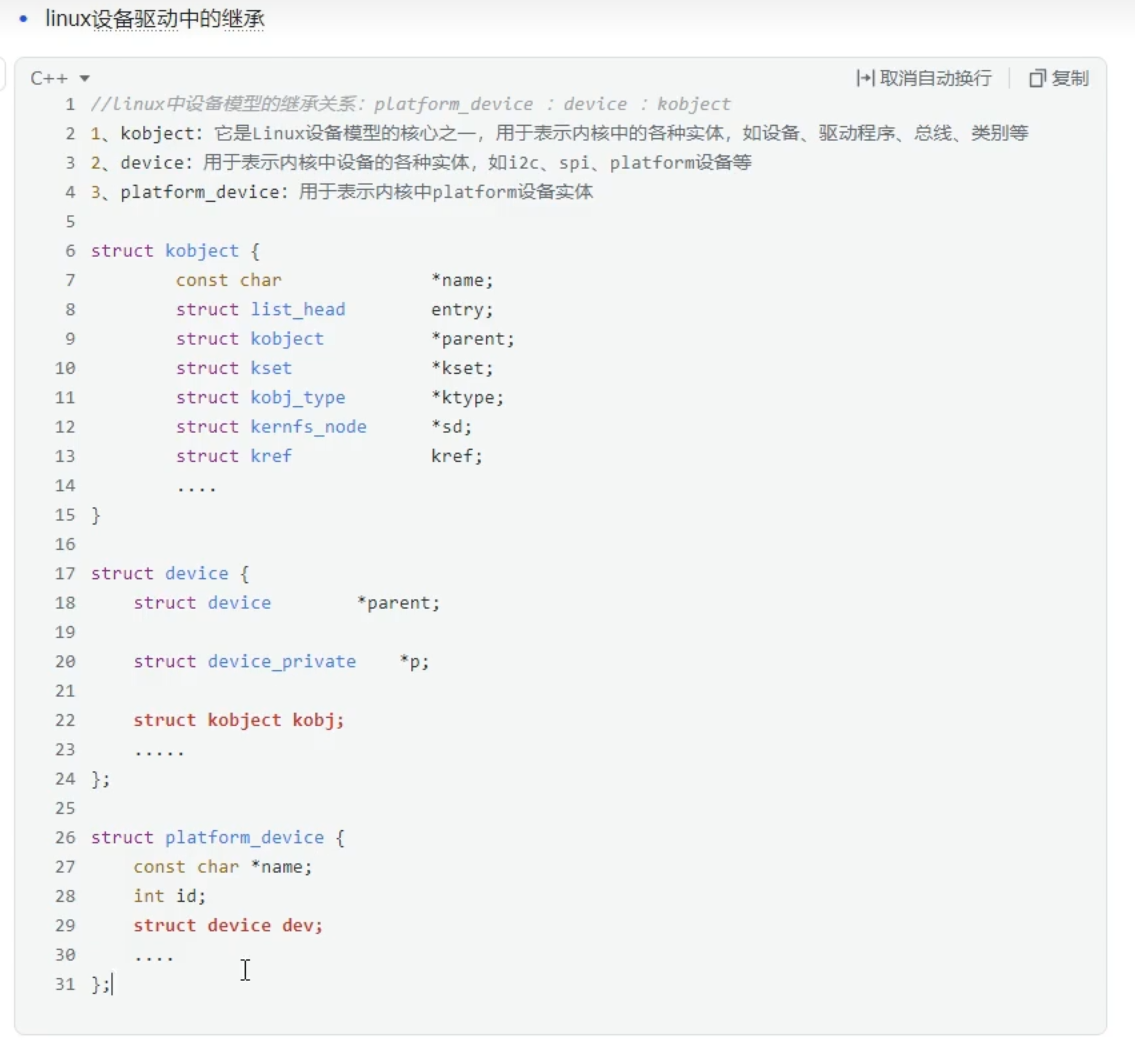

## 3. C与”封装”
封装的概念是指:将抽象的数据和行为(或者方法)相结合，形成一个有机的整体。是面向对象思想的核心，目的是增强安全性和简化编程，使用者不必理解具体的实现细节，通过调用接口使用数据成员。

### 3.1 C与"封装"

下面是c++的代码，如何通过c语言对下面例子进行改造，实现封装

In [ ]:
#include <iostream>
using namespace std;
//基类
class shape{
protected:
    int width;
    int height;
public:
    void setWidth(int w) {
        width = w;
    }
    void setHeight(int h) {
        height = h;
    }
    int getWidth() {
        return this->width;
    }
    int getHeight() {
        return this->height;
    }
};
int main(void){
    shape s;
    s.setWiddth(5);
    s.setHeight(7);
    cout << "width: " << s.getWidth() << endl;
    cout << "height: " << s.getHeight() << endl;
    return 0;
}

C语言实现封装

In [ ]:
#include <stdio.h>
#include <string.h>
//基类
struct shape{
    int width;
    int height;
    void (*setWidth)(struct shape* s, int w);
    void (*setHeight)(struct shape* s, int h);
    int (*getWidth)(struct shape* s);
    int (*getHeight)(struct shape* s);
};
void setWidth(struct shape* s, int w){
    s->width = w;
}
void setHeight(struct shape* s, int h){
    s->height = h;
}
int getWidth(struct shape* s){
    return s->width;
}
int getHeight(struct shape* s){
    return s->height;
}

int main(void){
    struct shape s = {
        .setWidth = setWidth,
        .setHeight = setHeight
    };
    s.setWidth(&s, 5);
    s.setHeight(&s, 7);
    printf("width: %d\n", getWidth(&s));
    printf("height: %d\n", getHeight(&s));
    return 0;
}

区别是c++的类有this指针，可以访问到自己的内容，而c语言没有，所以需要把自己作为参数传进去

### 3.2 linux文件系统中inode的设计

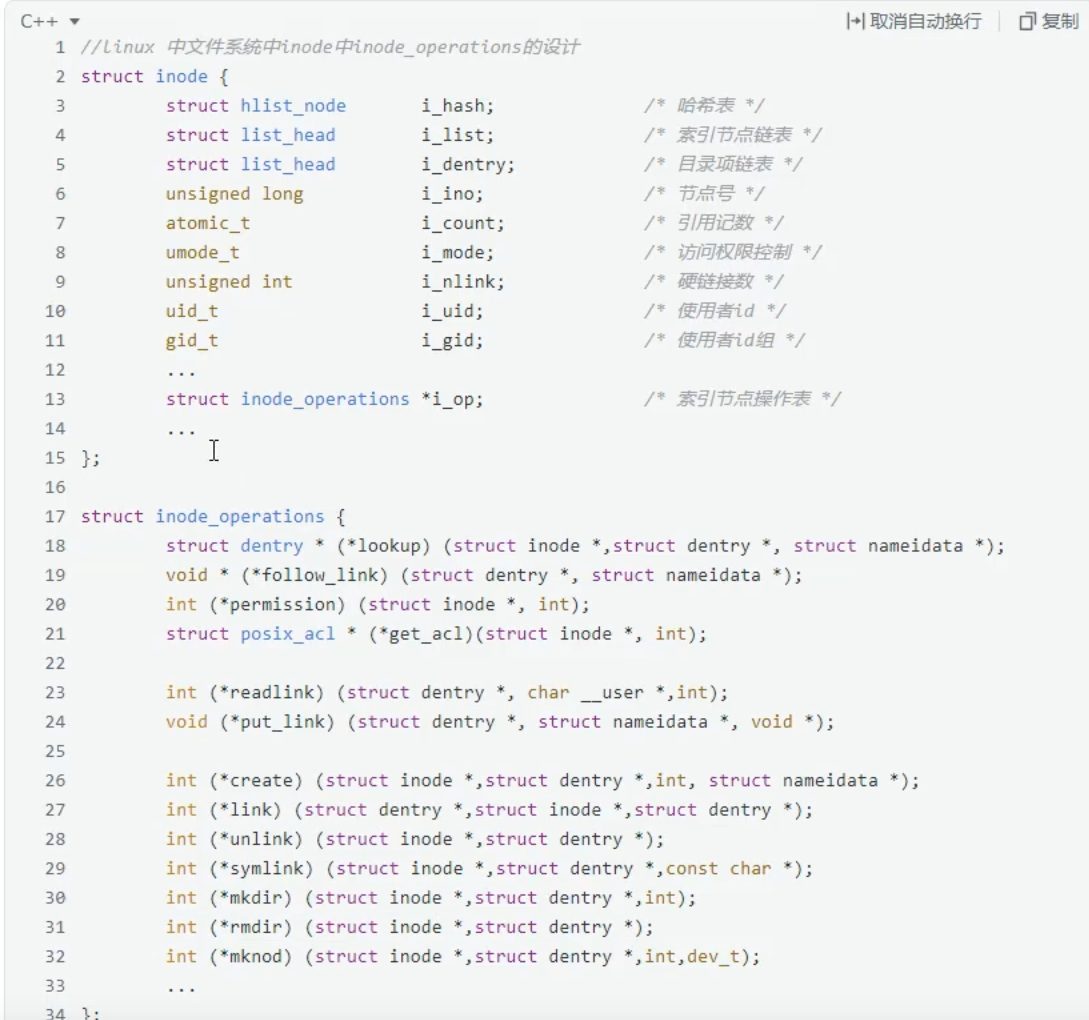

## 4. C与“多态”

### 4.1 C与"多态"
多态的概念是指:通过父类的指针来调用子类中的方法，作用是把不同的子类对象当做父类来看，屏蔽不同子类之间的差异，用于适应需求的不断变化，本质上是面向抽象编程，在C++中，多态的实现是通过虚函数来实现。体会一下以下这个例子:

In [ ]:
#include <stdio.h>
#include <string.h>

class person{
protected:
    char name[24];
    int age;
public:
    virtual void get_name(char *n) {
        strcpy(n, name);
    }

    person(const char *n, int a) {
        strcpy(name, n); 
        age = a;
    }
};

class usa_person : public person {
public:
    usa_person(const char *n, int a) : person(n, a) {

    }
    void get_name(char *n) {//重写父类的虚函数
        sprintf(n, "%s", name);
        sprintf(n + strlen(n), "%s", "-usa");
    }
};


class china_person : public person {
public:
    china_person(const char *n, int a) : person(n, a) {//这里要使用:person(n, a)来调用父类的构造函数进行初始化，否则父类的成员变量name和age就没有被正确初始化，导致后续调用get_name函数时无法正确获取name的值。
        
    }
    void get_name(char *n) {
        sprintf(n, "%s", name);
        sprintf(n + strlen(n), "%s", "-china");
    }
};
int main(void){
    char name[32];
    person *p1 = new usa_person("Tom", 20);
    person *p2 = new china_person("Li", 30);
    p1->get_name(name);
    printf("name: %s\n", name);
    p2->get_name(name);
    printf("name: %s\n", name);
    delete p1;
    delete p2;
    return 0;
}

c语言实现多态：

In [ ]:
#include <stdio.h>
#include <string.h>

struct person{
    char name[20];
    int age;
    void (* get_name)(struct person * p, char * name);
};
struct usa_person{
    struct person p;
    void (* get_name)(struct person * p, char * name);
};

static void get_name(struct person * p, char * name){
    struct usa_person * child = (struct usa_person *)p;//强制转换成子类指针
    child->get_name(p, name);//调用子类的函数指针
}
static void get_name_usa(struct person * p, char * name){
    sprintf(name, "%s-usa", p->name);
}

static struct usa_person us_p = {
    .p = {
        .name = "Tom",
        .age = 20,
        .get_name = get_name
    },
    .get_name = get_name_usa
};

int main(void){
    
    char name[20];
    //us_p.get_name(&us_p.p, name);
    struct person* p = (struct person*)&us_p.p;
    p->get_name(p, name);
    printf("name is %s\n", name);
    return 0;
}

### 4.2 Linux内核中设备驱动中的多态：
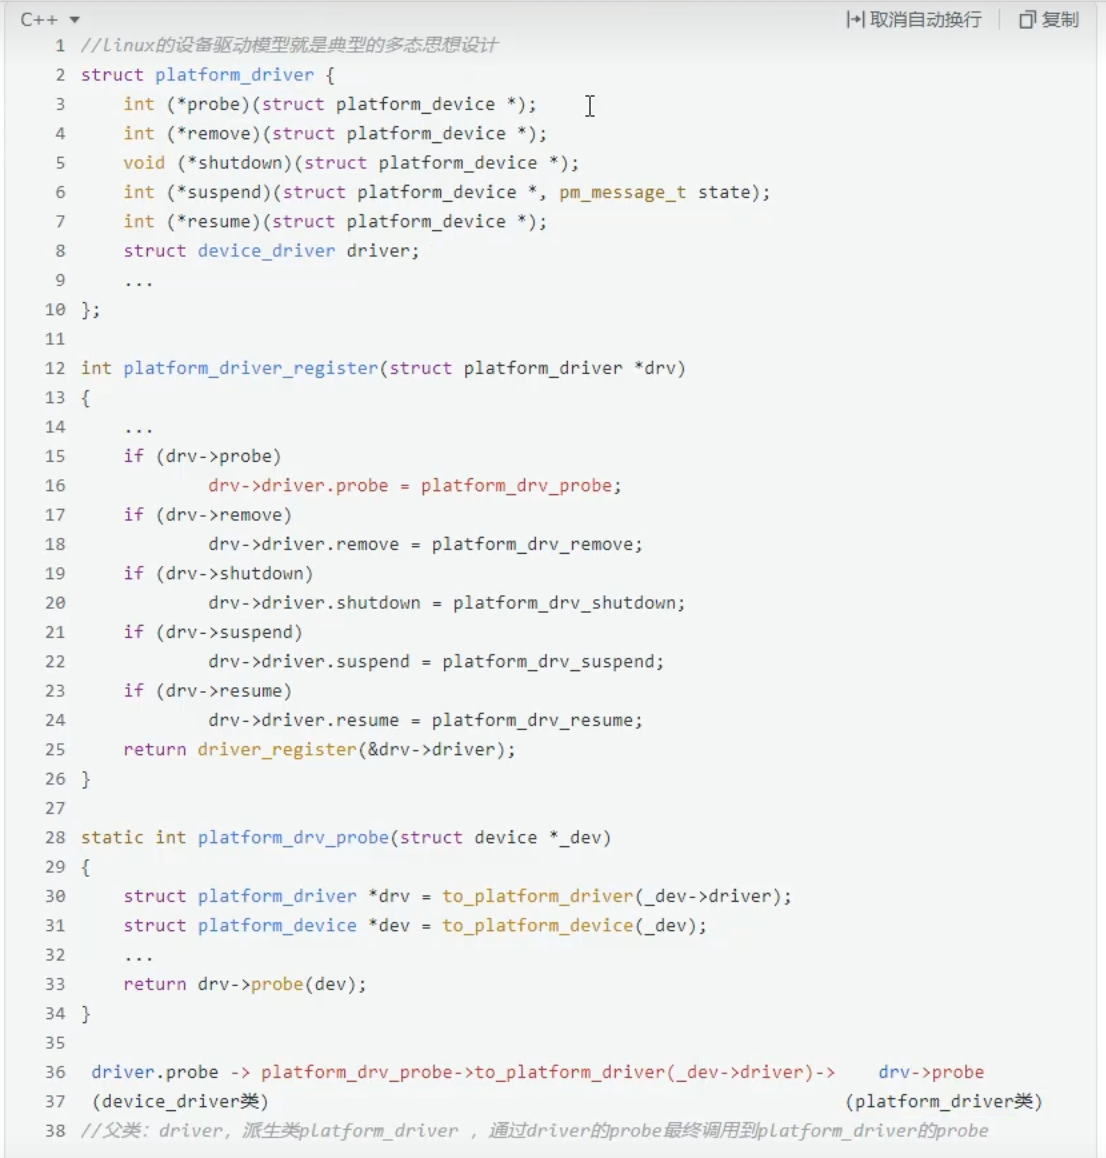

## 5. C与"重载"
重载的概念是指:在同一个范围中声明几个同名函数，但同名函数的形参不同(个数、类型、顺序)，一般是用来处理功能类似但是数据类型不同的问题。严格意义上C的编译器不支持重载，但我们有一些方法达到相同的目的

### 5.1 C中典型有重载效果的函数

In [ ]:
//printf函数是C中典型有重载效果的函数#include <stdio.h>
int main(void)
{
    printf("%s \n", "hello world");
    printf("%s %s \n", "hello world 1", "hello world 2");
    printf("%d %s \n", 10, "hello world 1");
    printf("%s %d \n", "hello world 1", 10);
    return 0;
}

`c语言中可以通可变参数函数实现重载的效果，典型的函数就是printf函数，printf函数的第一个参数是格式字符串，根据格式字符串的不同，可以传入不同类型和数量的参数，从而实现了重载的效果。`

C 语言通过<stdarg.h>头文件提供可变参数支持，C++ 继承了这一机制并扩展了更安全的实现。

核心宏
- va_list：存储可变参数列表的类型「一个元素的结构体数组」
- va_start(ap, last)：初始化va_list，last是最后一个「定位到可变参数的地址」
  
固定参数
- va_arg(ap, type)：获取下一个参数，指定类型type「遍历可变参数」
- va_end(ap)：清理va_list「终止va_list遍历」

### 5.2 c通过可变参数函数实现求和函数

In [ ]:
#include <stdio.h>
#include <stdarg.h>

// 第一个参数是参数个数，后面是可变参数
int sum(int count, ...) {
    va_list ap;
    int total = 0;
    
    va_start(ap, count); // 初始化参数列表
    for (int i = 0; i < count; i++) {
        total += va_arg(ap, int); // 逐个读取int类型参数
    }
    va_end(ap); // 清理
    
    return total;
}

int main() {
    printf("Sum: %d\n", sum(3, 1, 2, 3)); // 输出6
    printf("Sum: %d\n", sum(5, 10, 20, 30, 40, 50)); // 输出150
    return 0;
}